In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytanie danych i poprawne parsowanie czasu
# Używamy pd.to_datetime, aby poprawnie obliczyć dt w sekundach

dane_normalne = pd.read_excel("Przebieg normalny.xlsx")
dane_zaburzone = pd.read_excel("Przebieg zaburzony.xlsx")



In [6]:
dt = 1.0  # krok 1 sekunda

def przygotuj_sygnaly(df):
    # Temperatury y i z dzielimy przez 10 (zgodnie z wytycznymi: 235 -> 23.5)
    temp_obiektu = df["y (T)"].values / 10.0
    temp_otoczenia = df["z (Tz)"].values / 10.0
    moc_grzalki = df["u (Pg)"].values
    return temp_obiektu, temp_otoczenia, moc_grzalki

y_norm, z_norm, u_norm = przygotuj_sygnaly(dane_normalne)
y_zab, z_zab, u_zab = przygotuj_sygnaly(dane_zaburzone)

In [7]:
# Zad 1 i 2: Wyznaczenie parametrów c i d metodą MNK
# Model dyskretny: y[n+1] = y[n] + (dt/c)*u[n] + (d*dt/c)*(z[n] - y[n])
# Równanie regresji: delta_y = a*u + b*(z-y)
# gdzie a = dt/c, b = d*dt/c

roznica_y = y_norm[1:] - y_norm[:-1]
macierz_regresji = np.column_stack([
    u_norm[:-1], 
    z_norm[:-1] - y_norm[:-1]
])

In [8]:
# Rozwiązanie układu (Metoda Najmniejszych Kwadratów)
parametry_pomocnicze, _, _, _ = np.linalg.lstsq(macierz_regresji, roznica_y, rcond=None)
a_mnk, b_mnk = parametry_pomocnicze

# Wyliczenie parametrów fizycznych c i d
c_wynik = dt / a_mnk
d_wynik = b_mnk / a_mnk

print(f"Zidentyfikowane parametry: c = {c_wynik:.2f}, d = {d_wynik:.4f}")

Zidentyfikowane parametry: c = 25378.89, d = 10.5507


In [13]:
# Zad 3 i 4: Predykcja z horyzontem h
def oblicz_predykcje(y_dane, u_dane, z_dane, a, b, horyzont):
    n_probek = len(y_dane)
    y_pred = np.full(n_probek, np.nan)
    
    # Zgodnie z Rys. 1: startujemy z rzeczywistego y[n-h] i robimy h kroków modelem
    for n in range(horyzont, n_probek):
        wartosc_startowa = y_dane[n - horyzont]
        temp_sym = wartosc_startowa
        
        for k in range(horyzont):
            idx = n - horyzont + k
            # Iteracja modelu dyskretnego
            temp_sym = temp_sym + a * u_dane[idx] + b * (z_dane[idx] - temp_sym)
        
        y_pred[n] = temp_sym
    return y_pred

horyzonty = [1, 10, 30, 60] # h=1s, h=10s, h=60s (1 minuta)
wyniki_predykcji = {h: oblicz_predykcje(y_norm, u_norm, z_norm, a_mnk, b_mnk, h) for h in horyzonty}

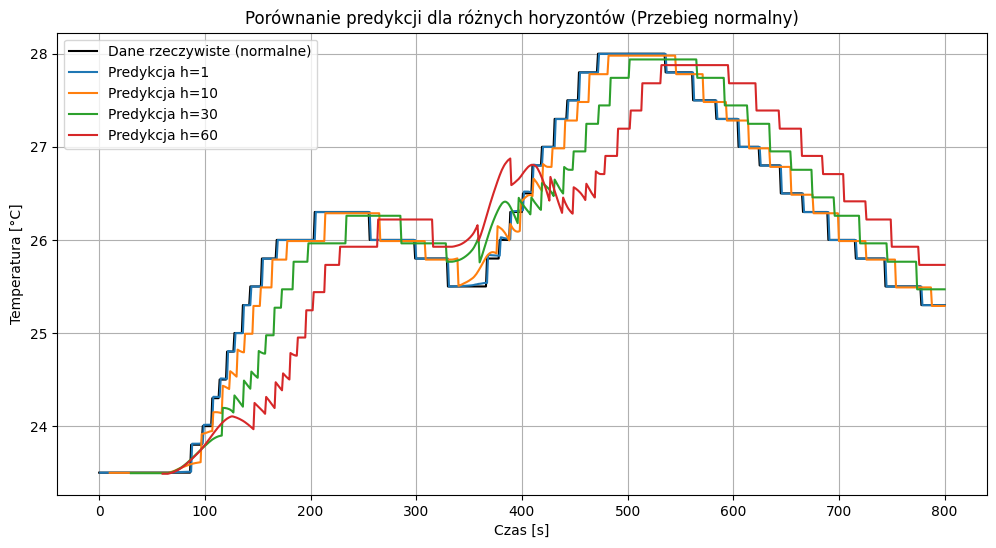

In [14]:
# Wykres porównawczy predykcji
plt.figure(figsize=(12, 6))
plt.plot(y_norm, label="Dane rzeczywiste (normalne)", color='black', linewidth=1.5)
for h in horyzonty:
    plt.plot(wyniki_predykcji[h], label=f"Predykcja h={h}")
plt.title("Porównanie predykcji dla różnych horyzontów (Przebieg normalny)")
plt.xlabel("Czas [s]")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# CZĘŚĆ (ii)
# Zad 1, 2 i 3: Reszty predykcji dla danych normalnych i zaburzonych
h_wybrane = 30 # Przykładowy horyzont do analizy anomalii (30 sekund)

predykcja_zab = oblicz_predykcje(y_zab, u_zab, z_zab, a_mnk, b_mnk, h_wybrane)
reszty_norm = y_norm - wyniki_predykcji[h_wybrane]
reszty_zab = y_zab - predykcja_zab


# 3. Statystyki i próg (Zad 5)
sigma = np.nanstd(reszty_norm)
prog_epsilon = 3 * sigma

print(f"Analiza dla horyzontu h = {h_wybrane}:")
print(f"Odchylenie standardowe (sigma): {sigma:.4f}")
print(f"Proponowany próg detekcji (3*sigma): {prog_epsilon:.4f}")

Analiza dla horyzontu h = 30:
Odchylenie standardowe (sigma): 0.3682
Proponowany próg detekcji (3*sigma): 1.1047


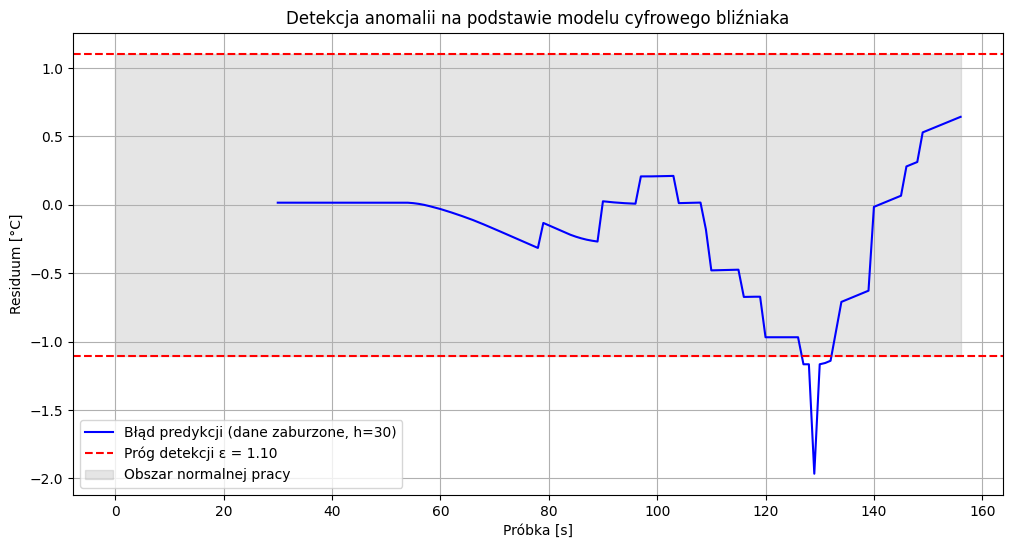

In [20]:
# 4. Wykres residuów (Zad 3 i 4)
plt.figure(figsize=(12, 6))
plt.plot(reszty_zab, label=f"Błąd predykcji (dane zaburzone, h={h_wybrane})", color='blue')
plt.axhline(y=prog_epsilon, color='red', linestyle='--', label=f"Próg detekcji ε = {prog_epsilon:.2f}")
plt.axhline(y=-prog_epsilon, color='red', linestyle='--')
plt.fill_between(range(len(reszty_zab)), -prog_epsilon, prog_epsilon, color='gray', alpha=0.2, label="Obszar normalnej pracy")

plt.title("Detekcja anomalii na podstawie modelu cyfrowego bliźniaka")
plt.xlabel("Próbka [s]")
plt.ylabel("Residuum [°C]")
plt.legend()
plt.grid(True)
plt.show()


--- Analiza statystyczna dla różnych horyzontów (Zad. 5) ---
Horyzont h= 1: średnia=  0.0008, sigma=  0.0531, próg 3σ=  0.1593
Horyzont h=10: średnia=  0.0083, sigma=  0.1614, próg 3σ=  0.4842
Horyzont h=30: średnia=  0.0268, sigma=  0.3682, próg 3σ=  1.1047
Horyzont h=60: średnia=  0.0613, sigma=  0.6764, próg 3σ=  2.0292


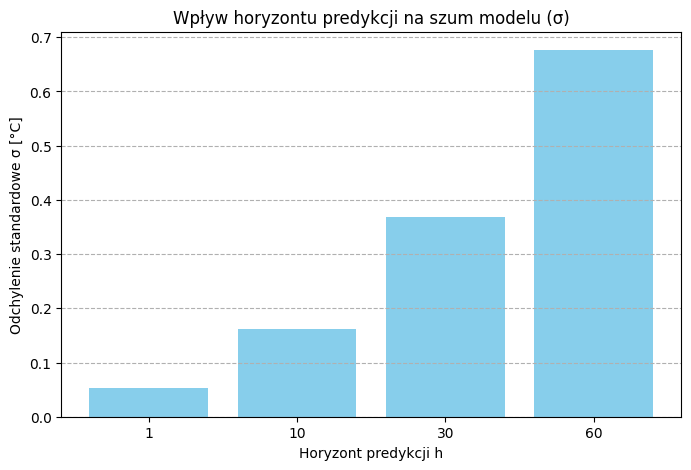

In [21]:
# ZADANIE 5: ANALIZA STATYSTYCZNA RESIDUÓW (σ)
# =============================================================================

print("\n--- Analiza statystyczna dla różnych horyzontów (Zad. 5) ---")

wyniki_sigma = {}

for h in horyzonty:
    # Obliczamy reszty dla przebiegu normalnego
    r_norm = y_norm - wyniki_predykcji[h]
    
    # Wyznaczamy średnią (powinna być bliska 0) i odchylenie standardowe sigma
    mu = np.nanmean(r_norm)
    sigma = np.nanstd(r_norm)
    
    wyniki_sigma[h] = sigma
    
    print(f"Horyzont h={h:2}: średnia={mu:8.4f}, sigma={sigma:8.4f}, próg 3σ={3*sigma:8.4f}")

# Opcjonalnie: Wykres słupkowy pokazujący jak rośnie błąd wraz z horyzontem
plt.figure(figsize=(8, 5))
plt.bar([str(h) for h in horyzonty], [wyniki_sigma[h] for h in horyzonty], color='skyblue')
plt.xlabel("Horyzont predykcji h")
plt.ylabel("Odchylenie standardowe σ [°C]")
plt.title("Wpływ horyzontu predykcji na szum modelu (σ)")
plt.grid(axis='y', linestyle='--')
plt.show()

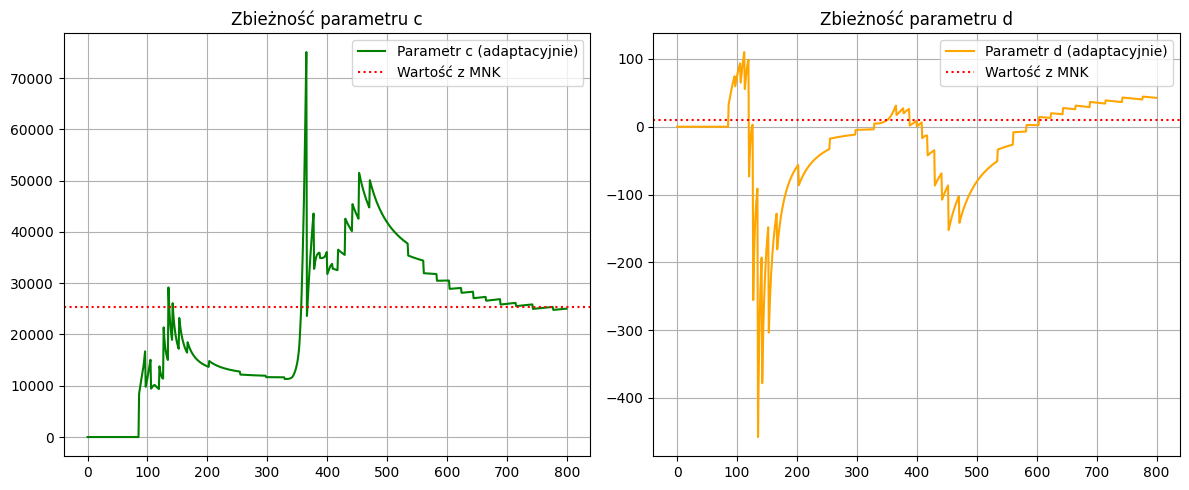

In [22]:
# ZADANIE 6: ADAPTACYJNE WYZNACZANIE PARAMETRÓW (RLS)
# =============================================================================

def rls_identyfikacja(u_syg, y_syg, z_syg, dt_krok):
    N = len(y_syg)
    # Macierz kowariancji P i wektor parametrów theta [a, b]
    P = np.eye(2) * 1000.0
    theta = np.array([0.0, 0.0])
    zapominanie = 0.995 # lambda (opcjonalnie dla lepszej adaptacji)
    
    historia_c = []
    historia_d = []
    
    for n in range(N-1):
        phi = np.array([u_syg[n], z_syg[n] - y_syg[n]])
        y_rzeczywiste = y_syg[n+1] - y_syg[n]
        
        # Algorytm RLS
        blad = y_rzeczywiste - phi.dot(theta)
        K = P.dot(phi) / (zapominanie + phi.dot(P).dot(phi))
        theta = theta + K * blad
        P = (P - np.outer(K, phi.dot(P))) / zapominanie
        
        # Konwersja na parametry fizyczne c i d
        a_akt, b_akt = theta
        curr_c = dt_krok / a_akt if a_akt != 0 else 0
        curr_d = b_akt / a_akt if a_akt != 0 else 0
        
        historia_c.append(curr_c)
        historia_d.append(curr_d)
        
    return historia_c, historia_d

c_adapt, d_adapt = rls_identyfikacja(u_norm, y_norm, z_norm, dt)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(c_adapt, label="Parametr c (adaptacyjnie)", color='green')
plt.axhline(y=c_wynik, color='r', linestyle=':', label="Wartość z MNK")
plt.legend()
plt.title("Zbieżność parametru c")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(d_adapt, label="Parametr d (adaptacyjnie)", color='orange')
plt.axhline(y=d_wynik, color='r', linestyle=':', label="Wartość z MNK")
plt.legend()
plt.title("Zbieżność parametru d")
plt.grid(True)
plt.tight_layout()
plt.show()